In [1]:
from instance_generator import instance_generator
K = 5
T_d = 20
C_k = [20] * K
done = False
instance = instance_generator(T_d, K)
print(instance)

[[7.319055060733261, 2, 2, 2, 3, 0], [5.7105129653426205, 2, 2, 3, 0, 0], [11.140695006534306, 3, 3, 0, 0, 0], [10.89972470857739, 3, 1, 0, 0, 0], [10.30354729306495, 1, 0, 0, 0, 0], [9.41453922871818, 2, 3, 1, 2, 0], [9.888676777841885, 1, 1, 2, 1, 0], [6.361696205382655, 3, 2, 1, 1, 0], [10.542742639682588, 3, 2, 1, 0, 0], [5.554317471474113, 3, 1, 2, 2, 0], [14.714274008383246, 1, 0, 0, 0, 0], [9.71512856334115, 1, 4, 2, 1, 0], [11.149216208800107, 4, 3, 2, 2, 2], [10.059957603909917, 2, 3, 2, 0, 0], [13.674018931668053, 1, 1, 1, 0, 0], [14.65516430938689, 2, 0, 0, 0, 0], [13.518969550403044, 2, 1, 0, 0, 0], [5.607223259447141, 4, 2, 1, 2, 1], [12.476332529059224, 2, 0, 0, 0, 0], [12.96925338719035, 1, 3, 2, 1, 0]]


Further we can load the benachmark data from the CI project

In [2]:
from instance_reader import get_instance_data
from pathlib import Path

data_path = Path("../instances/lion18s/SA01.txt")

DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = DRAUSP_data.num_requests
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
print(K)
print(T_d)
print(C_k)
print(instance)

[10, 10, 10, 10]
4
50
[10, 10, 10, 10]
[[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79, 1, 2, 0, 0], [9, 1, 2, 0, 0]]


### State space: 
$\mathcal{S} = (t, \hat{C}, r, q) \in \R^{2K+2}$ with $t \in \N$, $\hat{C} \in \{0,1,\dots,C_1\} \times \dots \times \{0,1,\dots,C_K\} \in \N^K$, $r \in \R$ and $q \in \N^K$,   
such that $t$ refers to the actual period, $C$ is the vector of remaining capacitities in each time slot and the pair $[r,q]$ is the next request to schedule with profit $r$ and demanded capacity $q$.
  
Intital state: $S_1 = (1,C_1, \dots, C_K, r_1, q_1)$

### Actions:
Receiving a new request $[r_i,q_i]$:  
We can either decline the request which leads to a revenue of $0$ or we can accept the request, which yields to a revenue of $r_i$.  
Accepting the request we need to do an additional decision where to place the order. There are $K-len(q_i)+1$ different possibilities on how to schedule the request.  
There are $K+1$ different actions ($\mathcal{A} = \{0,1,\dots,K\}$) with the following transition function $\mathcal{T}: \mathcal{S} \times {\mathcal{A}} \rightarrow \mathcal{S}$. Let $S_i = (t,\hat{C}_1, \dots \hat{C}_K)$  
  
$0$: Decline the order --> $S_{i+1} = (t+1, \hat{C}_1, \dots \hat{C}_K, r_{i+1}, q_{i+1})$  
$1$: Accept the order on time slot 1  --> $S_{i+1} = (t+1, \hat{C}_1 - q_i^1, \dots, \hat{C}_{len(q_i)} - q_i^{len(q_i)}, \dots \hat{C}_K, r_{i+1}, q_{i+1})$  
$\vdots$  
$K$: Accept the order on time slot K --> $S_{i+1} = (t+1, \hat{C}_1 , \dots, \hat{C}_K - q_i^1, r_{i+1}, q_{i+1})$  
  
We need to pay attention to not allow accepting the order on time slot $l$ s.t. $l + len(q_i) > K$. We do this by violating this case with a highly negative reward and finishiing the trajectory.

We need to define a transition function $\mathcal{S} \times \mathcal{A} \rightarrow \mathcal{S}$ and a reward function $\mathcal{S} \times \mathcal{A} \rightarrow \R$

In [3]:
def length_of_requests(state, K):
    q = state[K+2:] 
    for i, val in enumerate(q):
        if val == 0:
            return i
    return len(q)

def transition(state, action):
    state = list(state)
    if state[0] == T_d:
        print("End of episode")
        return state, 0, True
    len_q = length_of_requests(state, K)
    if len_q + action - 1 > K: # End of trajectory
        print("End of trajectory")
        done = True
        reward = -100
        return state, reward, done
    if action == 0:
        new_state = [state[0]+1] + state[1:K+1] + [instance[state[0]][0]] + instance[state[0]][1:K+1]
        reward = 0
    else:
        new_state = [state[0] +1] + state[1:action] + [state[action + i] - state[K+2+i] for i in range(len_q)] + state[action + len_q : K + 1] + [instance[state[0]][0]] + instance[state[0]][1:K+1]
        reward = state[K+1]    #profit of accepting current request
    if all(c >= 0 for c in new_state[1:K+1]):
        return new_state, reward, False     # feasible choice
    else:
        done = True
        return new_state, -100, done
    
def initial_state(instance, K):
    return [1] + C_k + [instance[0][0]] + instance[0][1:K+1]

def get_valid_actions(state, K):
    valid_actions = [0]  # Always can reject
    len_q = length_of_requests(state, K)
    for a in range(1, K + 2 - len_q):
        valid = True
        for i in range(len_q):
             if state[a + i] < state[K + 2 + i ]:  # Check if accepting is feasible for all requests
                valid = False
                break
        if valid:
            valid_actions.append(a)
    return valid_actions


In [4]:
instance

[[41, 1, 1, 0, 0],
 [39, 1, 1, 0, 0],
 [20, 1, 3, 0, 0],
 [61, 2, 1, 0, 0],
 [18, 2, 1, 0, 0],
 [23, 1, 4, 0, 0],
 [25, 1, 1, 0, 0],
 [13, 1, 1, 0, 0],
 [77, 1, 1, 0, 0],
 [8, 1, 2, 0, 0],
 [25, 1, 3, 0, 0],
 [74, 1, 1, 0, 0],
 [39, 1, 3, 0, 0],
 [54, 3, 2, 0, 0],
 [70, 1, 3, 0, 0],
 [71, 1, 1, 0, 0],
 [55, 1, 1, 0, 0],
 [9, 1, 1, 0, 0],
 [96, 1, 1, 0, 0],
 [63, 3, 2, 0, 0],
 [50, 3, 2, 0, 0],
 [20, 1, 1, 0, 0],
 [43, 1, 2, 0, 0],
 [74, 1, 2, 0, 0],
 [62, 1, 1, 0, 0],
 [60, 1, 1, 0, 0],
 [22, 1, 1, 0, 0],
 [81, 1, 2, 0, 0],
 [92, 1, 1, 0, 0],
 [80, 1, 1, 0, 0],
 [38, 2, 1, 0, 0],
 [84, 1, 1, 0, 0],
 [39, 1, 2, 0, 0],
 [88, 2, 1, 0, 0],
 [69, 1, 3, 0, 0],
 [21, 2, 1, 0, 0],
 [15, 1, 1, 0, 0],
 [47, 3, 1, 0, 0],
 [67, 1, 1, 0, 0],
 [18, 1, 1, 0, 0],
 [87, 1, 1, 0, 0],
 [58, 1, 2, 0, 0],
 [34, 2, 1, 0, 0],
 [8, 1, 1, 0, 0],
 [97, 1, 1, 0, 0],
 [73, 1, 1, 0, 0],
 [54, 1, 1, 0, 0],
 [69, 2, 1, 0, 0],
 [79, 1, 2, 0, 0],
 [9, 1, 2, 0, 0]]

In [5]:
state_0 = initial_state(instance, K)
(state_1, reward, done) = transition(state_0, 1)
print(state_1)
print(reward)
print(done)
(state_2, reward, done) = transition(state_1, 1)
print(state_2)
print(reward)
print(done)
(state_3, reward, done) = transition(state_2, 1)
print(state_3)
print(reward)
print(done)
print(get_valid_actions(state_3, K))
(state_4, reward, done) = transition(state_3, 1)
print(state_4)
print(reward)
print(done)
print(get_valid_actions(state_4, K))

[2, 9, 9, 10, 10, 39, 1, 1, 0, 0]
41
False
[3, 8, 8, 10, 10, 20, 1, 3, 0, 0]
39
False
[4, 7, 5, 10, 10, 61, 2, 1, 0, 0]
20
False
[0, 1, 2, 3]
[5, 5, 4, 10, 10, 18, 2, 1, 0, 0]
61
False
[0, 1, 2, 3]


## Apply DQN

In [6]:
import torch
import torch.nn as nn
import random
import torch.optim as optim

# Neural network model for approximating Q-values
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, output_dim)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)
    
# Epsilon-greedy action selection
def select_action(state, epsilon, policy_net):

    valid_actions = get_valid_actions(state, K) # we only want to select from valid actions

    if random.random() < epsilon:
        return random.choice(valid_actions)

    state_t = torch.FloatTensor(state).unsqueeze(0)

    with torch.no_grad():
        q_values = policy_net(state_t)[0]

    # mask invalid actions
    masked_q = torch.full_like(q_values, -1e9)
    masked_q[valid_actions] = q_values[valid_actions]

    return torch.argmax(masked_q).item()

In [7]:
input_dim = 2 * K + 2  # state representation size
output_dim = K + 1     # number of actions (0 to K)
num_episodes = 500
gamma = 0.9
replay_buffer = []
batch_size = 64
epsilon = 1.0
epsilon_min = 0.1
epsilon_decay = 0.995
reward_history = []

In [8]:
policy_net = DQN(input_dim, output_dim)
target_net = DQN(input_dim, output_dim)
target_net.load_state_dict(policy_net.state_dict())     # both NNs have same weights at the beginning
target_net.eval()  # target network is not trained directly


optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

In [9]:
def sample_replay_buffer(batch_size):
    batch = random.sample(replay_buffer, batch_size)

    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.tensor(states, dtype=torch.float32)
    actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
    rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1)
    next_states = torch.tensor(next_states, dtype=torch.float32)
    dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)

    return states, actions, rewards, next_states, dones

In [10]:
def train_step():
    batch = sample_replay_buffer(batch_size)

    states, actions, rewards, next_states, dones = batch

    # Q(s,a)
    q_values = policy_net(states)
    q_values = q_values.gather(1, actions)

    # Target Q
    with torch.no_grad():
        q_next = target_net(next_states)

        for i in range(batch_size):
            state_i = next_states[i].tolist()
            valid = get_valid_actions(state_i, K)

            mask = torch.ones(K+1) * -1e9
            mask[valid] = 0

            q_next[i] = q_next[i] + mask

        next_q_values = q_next.max(1, keepdim=True)[0]

        targets = rewards + gamma * (1 - dones) * next_q_values
    loss = loss_fn(q_values, targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

### Main training loop

In [11]:
step = 0
for episode in range(num_episodes):

    instance = instance_generator(T_d, K)
    state = initial_state(instance, K)
    done = False
    cumulated_reward = 0
    while not done:

        # 1. Aktion wählen
        action = select_action(state, epsilon, policy_net)
        #print(f"Episode {episode}, State: {state}, Action: {action}")
        # 2. Umgebungsschritt
        next_state, reward, done = transition(state, action)

        if reward == -100:
            print(state, action, reward, next_state, done)

        # 3. Replay Buffer speichern
        replay_buffer.append((state, action, reward, next_state, done))

        state = next_state
        cumulated_reward += reward

        # 4. Lernen (nur wenn genug Daten da sind)
        if len(replay_buffer) > 500 and step % 4 == 0:
            train_step()
        step += 1

    # 5. epsilon reduzieren
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    print(f"Episode {episode} finished with reward {cumulated_reward}")
    reward_history.append(cumulated_reward)

    # Update target network every 10 episodes
    if episode % 10 == 0:
        target_net.load_state_dict(policy_net.state_dict())

End of episode
Episode 0 finished with reward 111.5324505282377
End of episode
Episode 1 finished with reward 120.14810350202751
End of episode
Episode 2 finished with reward 106.84888644185621
End of episode
Episode 3 finished with reward 114.79292665963908
End of episode
Episode 4 finished with reward 82.97447135484286
End of episode
Episode 5 finished with reward 81.98755002573607
End of episode
Episode 6 finished with reward 112.15574881421001
End of episode
Episode 7 finished with reward 150.50886492923084
End of episode
Episode 8 finished with reward 121.80249681602602
End of episode
Episode 9 finished with reward 97.48570617091234
End of episode
Episode 10 finished with reward 133.69652892212113
End of episode
Episode 11 finished with reward 89.83748680246889
End of episode
Episode 12 finished with reward 102.00324384607825
End of episode
Episode 13 finished with reward 118.83616546505152
End of episode
Episode 14 finished with reward 106.31403078074631
End of episode
Episode 15

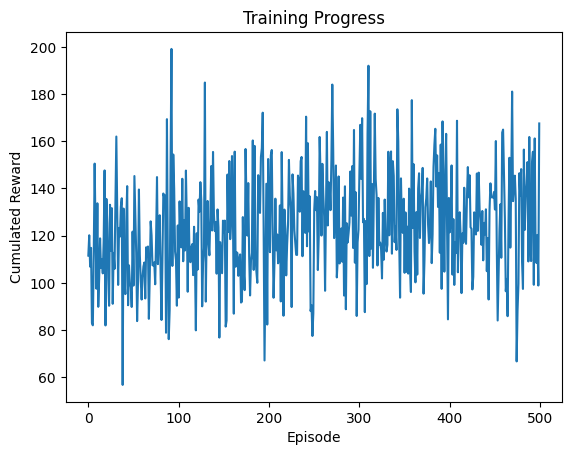

In [12]:
import matplotlib.pyplot as plt

plt.plot(reward_history)
plt.xlabel('Episode')
plt.ylabel('Cumulated Reward')
plt.title('Training Progress')
plt.show()